#**스마트폰 센서 데이터 기반 모션 분류**
# 단계3 : 단계별 모델링


## 0.미션4

* 단계별로 나눠서 모델링을 수행하고자 합니다.  
* 단계 구분 예시
    * 단계1 : 정적(0), 동적(1) 행동 분류 모델 생성
    * 단계2 : 세부 동작에 대한 분류모델 생성
        * 단계1 모델에서 0으로 예측 -> 정적 행동 3가지 분류 모델링
        * 단계1 모델에서 1으로 예측 -> 동적 행동 3가지 분류 모델링
* 모델 통합
    * 두 단계 모델을 통합하고, 새로운 데이터에 대해서 최종 예측결과와 성능평가가 나오도록 함수로 만들기
* 성능 비교
    * 기본 모델링의 성능과 비교
    * 성능 가이드
        * Accuracy : 0.97 ~ 0.99
* 파이프라인 구성
    * test 데이터를 입력하여, 전처리 및 예측결과가 나오도록 함수 구성

## 1.환경설정

* 세부 요구사항
    - 경로 설정 : 구글콜랩
        * 구글 드라이브 바로 밑에 project3 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### (1) 경로 설정

* 구글 드라이브 연결

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
path = '/content/drive/MyDrive/project3/'

### (2) 라이브러리 불러오기

* 라이브러리 로딩

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *
from sklearn.ensemble import RandomForestClassifier

from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Input, LSTM
from keras.backend import clear_session
from keras.optimizers import Adam

from keras.regularizers import l1, l2
from keras.callbacks import ModelCheckpoint, EarlyStopping

from tensorflow.keras.callbacks import LearningRateScheduler, ReduceLROnPlateau
import math

from tensorflow.keras import backend as K
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, BatchNormalization, Bidirectional, Layer, SpatialDropout1D


In [8]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
# 변수의 특성 중요도 계산하기
def plot_feature_importance(importance, names, result_only = False, topn = 'all'):
    feature_importance = np.array(importance)
    feature_name = np.array(names)

    data={'feature_name':feature_name,'feature_importance':feature_importance}
    fi_temp = pd.DataFrame(data)

    #변수의 특성 중요도 순으로 정렬하기
    fi_temp.sort_values(by=['feature_importance'], ascending=False,inplace=True)
    fi_temp.reset_index(drop=True, inplace = True)

    if topn == 'all' :
        fi_df = fi_temp.copy()
    else :
        fi_df = fi_temp.iloc[:topn]

    #변수의 특성 중요도 그래프로 그리기
    if result_only == False :
        plt.figure(figsize=(10,20))
        sns.barplot(x='feature_importance', y='feature_name', data = fi_df)

        plt.xlabel('importance')
        plt.ylabel('feature name')
        plt.grid()

    return fi_df

### (3) 데이터 불러오기

* 주어진 데이터셋
    * data01_train.csv : 학습 및 검증용
    * data01_test.csv : 테스트용
    * feature.csv : feature 이름을 계층구조로 정리한 데이터

* 세부 요구사항
    * 칼럼 삭제 : data01_train.csv와 data01_test.csv 에서 'subject' 칼럼은 불필요하므로 삭제합니다.

#### 1) 데이터로딩

In [ ]:
df_train = pd.read_csv(path + 'data01_train.csv')
df_test = pd.read_csv(path + 'data01_test.csv')
features = pd.read_csv(path + 'features.csv')

In [ ]:
df_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,21,STANDING
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,15,LAYING
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,11,STANDING
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,17,WALKING
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,17,WALKING_DOWNSTAIRS


In [ ]:
# 불필요한 컬럼 삭제
df_train.drop('subject', axis=1, inplace=True)
df_test.drop('subject', axis=1, inplace=True)

#### 2) 기본 정보 조회

In [ ]:
# 전체 데이터의 행, 열 개수 확인
df_train.shape

(5881, 562)

In [ ]:
# 전체 데이터의 수치형 변수 분포 확인
df_train.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,...,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,0.274811,-0.017799,-0.109396,-0.603138,-0.509815,-0.604058,-0.628151,-0.525944,-0.605374,-0.465490,...,0.126955,-0.305883,-0.623548,0.008524,-0.001185,0.009340,-0.007099,-0.491501,0.059299,-0.054594
std,0.067614,0.039422,0.058373,0.448807,0.501815,0.417319,0.424345,0.485115,0.413043,0.544995,...,0.249176,0.322808,0.310371,0.339730,0.447197,0.608190,0.476738,0.509069,0.297340,0.278479
min,-0.503823,-0.684893,-1.000000,-1.000000,-0.999844,-0.999667,-1.000000,-0.999419,-1.000000,-1.000000,...,-0.965725,-0.979261,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.980143
25%,0.262919,-0.024877,-0.121051,-0.992774,-0.977680,-0.980127,-0.993602,-0.977865,-0.980112,-0.936067,...,-0.021610,-0.541969,-0.845985,-0.122361,-0.294369,-0.481718,-0.373345,-0.811397,-0.018203,-0.141555
50%,0.277154,-0.017221,-0.108781,-0.943933,-0.844575,-0.856352,-0.948501,-0.849266,-0.849896,-0.878729,...,0.133887,-0.342923,-0.712677,0.010278,0.005146,0.011448,-0.000847,-0.709441,0.182893,0.003951
75%,0.288526,-0.010920,-0.098163,-0.242130,-0.034499,-0.262690,-0.291138,-0.068857,-0.268539,-0.013690,...,0.288944,-0.127371,-0.501158,0.154985,0.285030,0.499857,0.356236,-0.511330,0.248435,0.111932
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,0.977344,0.478157,1.000000


In [ ]:
# 전체 데이터의 모든 변수 확인
df_train.columns

Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-skewness()', 'fBodyBodyGyroJerkMag-kurtosis()',
       'angle(tBodyAccMean,gravity)', 'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'Activity'],
      dtype='object', length=562)

## 2.데이터 전처리

* 세부 요구사항
    - Label 추가 : 1단계 모델을 위한 레이블 추가
    - train : val = 8 : 2 혹은 7 : 3
    - random_state 옵션을 사용하여 다른 모델과 비교를 위해 성능이 재현되도록 합니다.

### (1) 1단계 모델링을 위한 레이블

In [ ]:
# 동적 행동이면 1, 그게 아니면(정적 행동이면) 0

df_train['Activity'] = df_train['Activity'].apply(lambda x: 1 if x in ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS'] else 0)
df_train.rename(columns={'Activity': 'is_dynamic'}, inplace=True)
df_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",is_dynamic
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.487737,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,0
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.237820,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,0
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.535287,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,0
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.004012,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,1
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.157832,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,1


### (2) x, y 분리

In [ ]:
# x, is_dynamic을 이용하여 train과 validation으로 데이터 분할
target = 'is_dynamic'
x1 = df_train.drop(target,axis=1)
y1 = df_train.loc[:, target]

### (3) 스케일링


* 세부 요구사항
    - 스케일링을 필요로 하는 알고리즘 사용을 위해서 코드 수행
    - min-max 방식 혹은 standard 방식 중 한가지 사용.

### (4) 데이터 분할
* train, val 분할

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x1, y1, test_size=0.3, random_state=42)

In [ ]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

## **3.단계별 모델링**

### (1) 단계1

* 세부 요구사항
    * 적절한 단계로 구분한 후, 1단계를 분류하는 모델 생성
        * 예시 : 정적 행동(Laying, Sitting, Standing)과 동적 행동(동적 : Walking, Walking-Up, Walking-Down)을 구분하는 모델 생성.
    * 몇 가지 모델을 만들고 가장 성능이 좋은 모델을 선정하시오.

#### 1) 모델1

In [ ]:
# Step decay function
def step_decay(epoch):
    initial_lr = 0.001  # 초기 learning rate
    drop = 0.5         # learning rate 감소 비율
    epochs_drop = 10    # 몇 에포크마다 감소할지 설정
    lr = initial_lr * math.pow(drop, math.floor((1 + epoch) / epochs_drop))
    return lr

In [ ]:
# LearningRateScheduler 콜백 생성
# lr_scheduler = LearningRateScheduler(step_decay)

# 학습 중 학습률 자동 감소
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

In [ ]:
nfeatures = x_train.shape[1]
nfeatures

561

In [ ]:
x_train.shape

(4116, 561)

In [ ]:
dropout_num = 0.2

model1 = Sequential([Input(shape = (nfeatures, )),
                     Dense(128, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(64, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(32, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(16, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(8, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(1, activation = 'sigmoid')
                     ])
model1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                     │ (None, 128)                 │          71,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 8)                   │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 83,937 (327.88 KB)

 Trainable params: 83,441 (325.94 KB)

 Non-trainable params: 496 (1.94 KB)

Epoch 1/150
91/91 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7452 - loss: 0.5142 - val_accuracy: 0.9951 - val_loss: 0.2337 - learning_rate: 0.0010
Epoch 2/150
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9585 - loss: 0.1751 - val_accuracy: 0.9984 - val_loss: 0.0502 - learning_rate: 0.0010
Epoch 3/150
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9865 - loss: 0.0877 - val_accuracy: 0.9984 - val_loss: 0.0204 - learning_rate: 0.0010
Epoch 4/150
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9866 - loss: 0.0649 - val_accuracy: 0.9984 - val_loss: 0.0151 - learning_rate: 0.0010
Epoch 5/150
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9919 - loss: 0.0466 - val_accuracy: 0.9992 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 6/150
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9909 - loss: 0.0419 - val_accuracy: 0.9984 - val_loss: 0.0066 - learning_rate: 0.0010
Epoch 7/150
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9953 - loss: 0.0276 - val_acc

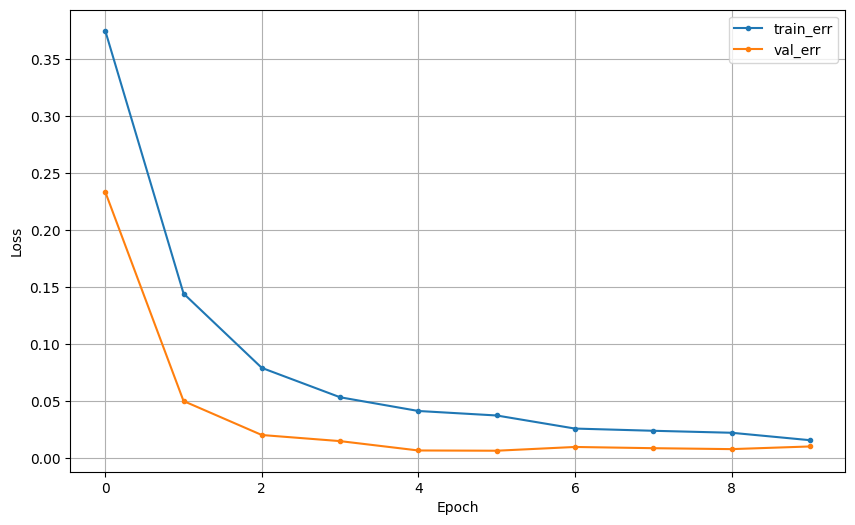

In [ ]:
model1.compile(optimizer = Adam(learning_rate=0.001), loss = 'binary_crossentropy', metrics=['accuracy'])




# EarlyStopping 설정 ------------
# min_delta 보다 개선이 안 됐으면 patience가 증가한다!!
min_de = 0.005  # 오차(loss)가 0.001이 되면 못참아.
pat = 5         # 5번까지는 오차 올라가는거 봐줄게.

es = EarlyStopping(monitor = 'val_loss', min_delta = min_de, patience = pat)
# --------------------------------


history1 = model1.fit(x_train, y_train, epochs=150, validation_split = 0.3, callbacks = [es, lr_scheduler]).history  # , callbacks = [mcp]

dl_history_plot(history1)

In [ ]:
pred1 = model1.predict(x_val)
pred1 = np.where(pred1 >= .5, 1, 0)
print(classification_report(y_val, pred1))

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       957
           1       1.00      1.00      1.00       808

    accuracy                           1.00      1765
   macro avg       1.00      1.00      1.00      1765
weighted avg       1.00      1.00      1.00      1765



#### 2) 모델2

### (2) 단계2

#### 1) 단계2-1 : 정적 동작 세부 분류

* 세부 요구사항
    * 정적 행동(Laying, Sitting, Standing)인 데이터 추출
    * Laying, Sitting, Standing 를 분류하는 모델을 생성
    * 몇가지 모델을 만들고 가장 성능이 좋은 모델을 선정하시오.

In [ ]:
df_train = pd.read_csv(path + 'data01_train.csv')
df_test = pd.read_csv(path + 'data01_test.csv')
features = pd.read_csv(path + 'features.csv')

In [ ]:
# 불필요한 컬럼 삭제
df_train.drop('subject', axis=1, inplace=True)
df_test.drop('subject', axis=1, inplace=True)

In [ ]:
df_train['Activity'].unique()

array(['STANDING', 'LAYING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS', 'SITTING'], dtype=object)

In [ ]:
# # Step decay function
# def step_decay(epoch):
#     initial_lr = 0.001  # 초기 learning rate
#     drop = 0.5         # learning rate 감소 비율
#     epochs_drop = 10    # 몇 에포크마다 감소할지 설정
#     lr = initial_lr * math.pow(drop, math.floor((1 + epoch) / epochs_drop))
#     return lr

In [ ]:
# LearningRateScheduler 콜백 생성
# lr_scheduler = LearningRateScheduler(step_decay)

# 학습 중 학습률 자동 감소
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

In [ ]:
u_data = df_train.loc[df_train['Activity'].isin(['LAYING', 'SITTING', 'STANDING'])].copy()
u_data['Activity'] = u_data['Activity'].map({'LAYING':0, 'SITTING':1, 'STANDING':2})
target = 'Activity'

x = u_data.drop(['Activity'], axis=1)
y = u_data.loc[:, target]

In [ ]:
y.unique()

array([2, 0, 1])

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.2, random_state = 20)

scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

In [ ]:
nfeatures = x_train.shape[1]
nfeatures

561

In [ ]:
dropout_num = 0.2

clear_session()

model2 = Sequential([Input(shape = (nfeatures, )),
                     Dense(128, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(64, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(32, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(16, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(8, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(3, activation = 'softmax')
                     ])
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          71,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8)                   │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 83,955 (327.95 KB)

 Trainable params: 83,459 (326.01 KB)

 Non-trainable params: 496 (1.94 KB)

Epoch 1/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.4740 - loss: 1.1417 - val_accuracy: 0.6371 - val_loss: 0.9470 - learning_rate: 0.0010
Epoch 2/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6420 - loss: 0.7663 - val_accuracy: 0.6358 - val_loss: 0.8288 - learning_rate: 0.0010
Epoch 3/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7182 - loss: 0.6256 - val_accuracy: 0.7169 - val_loss: 0.6266 - learning_rate: 0.0010
Epoch 4/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7777 - loss: 0.5198 - val_accuracy: 0.8674 - val_loss: 0.4273 - learning_rate: 0.0010
Epoch 5/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8378 - loss: 0.4277 - val_accuracy: 0.9408 - val_loss: 0.2763 - learning_rate: 0.0010
Epoch 6/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8810 - loss: 0.3656 - val_accuracy: 0.8777 - val_loss: 0.2952 - learning_rate: 0.0010
Epoch 7/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8939 - loss: 0.3056 - val_

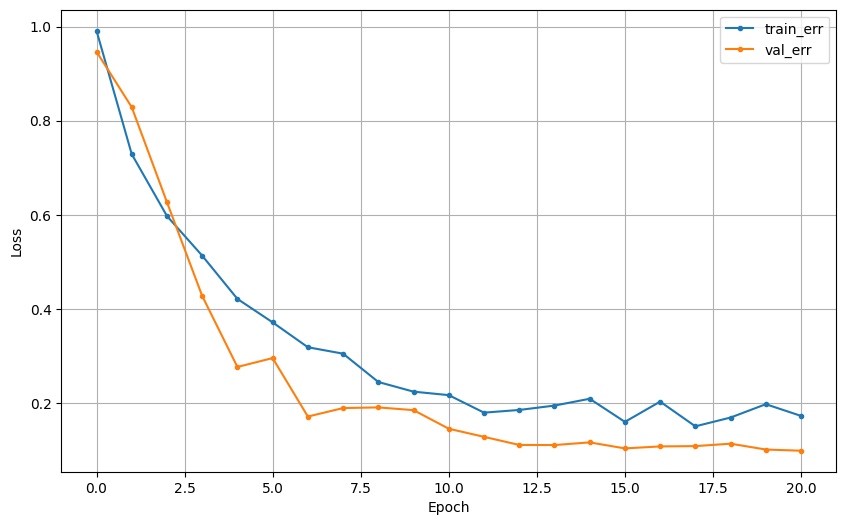

In [ ]:
model2.compile(optimizer = Adam(learning_rate=0.001), loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])


# EarlyStopping 설정 ------------
# min_delta 보다 개선이 안 됐으면 patience가 증가한다!!
min_de = 0.005  # 오차(loss)가 0.001이 되면 못참아.
pat = 5         # 5번까지는 오차 올라가는거 봐줄게.

es = EarlyStopping(monitor = 'val_loss', min_delta = min_de, patience = pat)
# --------------------------------


history2 = model2.fit(x_train, y_train, epochs=150, validation_split = 0.3, callbacks = [es, lr_scheduler]).history  # , callbacks = [mcp]

dl_history_plot(history2)

In [ ]:
pred = model2.predict(x_val)
pred_2 = pred.argmax(axis=1)
print(confusion_matrix(y_val, pred_2))
print(classification_report(y_val, pred_2))

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
[[222   2   0]
 [  0 194   7]
 [  0   6 216]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       224
           1       0.96      0.97      0.96       201
           2       0.97      0.97      0.97       222

    accuracy                           0.98       647
   macro avg       0.98      0.98      0.98       647
weighted avg       0.98      0.98      0.98       647



#### 2) 단계2-2 : 동적 동작 세부 분류

* 세부 요구사항
    * 동동적 행동(Walking, Walking Upstairs, Walking Downstairs)인 데이터 추출
    * Walking, Walking Upstairs, Walking Downstairs 를 분류하는 모델을 생성
    * 몇가지 모델을 만들고 가장 성능이 좋은 모델을 선정하시오.

In [ ]:
df_train = pd.read_csv(path + 'data01_train.csv')
df_test = pd.read_csv(path + 'data01_test.csv')
features = pd.read_csv(path + 'features.csv')

In [ ]:
# 불필요한 컬럼 삭제
df_train.drop('subject', axis=1, inplace=True)
df_test.drop('subject', axis=1, inplace=True)

In [ ]:
# 학습 중 학습률 자동 감소
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

In [ ]:
u_data = df_train.loc[df_train['Activity'].isin(['WALKING', 'WALKING_DOWNSTAIRS','WALKING_UPSTAIRS'])].copy()
u_data['Activity'] = u_data['Activity'].map({'WALKING':0, 'WALKING_DOWNSTAIRS':1, 'WALKING_UPSTAIRS':2})
target = 'Activity'

x3 = u_data.drop(['Activity'], axis=1)
y3 = u_data.loc[:, target]

In [ ]:
y.unique()

array([0, 1, 2])

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x3, y3, test_size=.2, random_state = 20)

scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

In [ ]:
nfeatures = x_train.shape[1]
nfeatures

561

In [ ]:
dropout_num = 0.2

clear_session()

model3 = Sequential([Input(shape = (nfeatures, )),
                     Dense(128, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(64, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(32, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(16, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(8, activation = 'relu'),
                     BatchNormalization(),
                     Dropout(dropout_num),
                     Dense(3, activation = 'softmax')
                     ])
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          71,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8)                   │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 83,955 (327.95 KB)

 Trainable params: 83,459 (326.01 KB)

 Non-trainable params: 496 (1.94 KB)

Epoch 1/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.3760 - loss: 1.1657 - val_accuracy: 0.4984 - val_loss: 1.0374 - learning_rate: 0.0010
Epoch 2/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6396 - loss: 0.8158 - val_accuracy: 0.7736 - val_loss: 0.8268 - learning_rate: 0.0010
Epoch 3/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7774 - loss: 0.6350 - val_accuracy: 0.9308 - val_loss: 0.5479 - learning_rate: 0.0010
Epoch 4/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8272 - loss: 0.5272 - val_accuracy: 0.9450 - val_loss: 0.3970 - learning_rate: 0.0010
Epoch 5/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8762 - loss: 0.3991 - val_accuracy: 0.9733 - val_loss: 0.2212 - learning_rate: 0.0010
Epoch 6/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8929 - loss: 0.3327 - val_accuracy: 0.9717 - val_loss: 0.1572 - learning_rate: 0.0010
Epoch 7/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9229 - loss: 0.2739 - val_ac

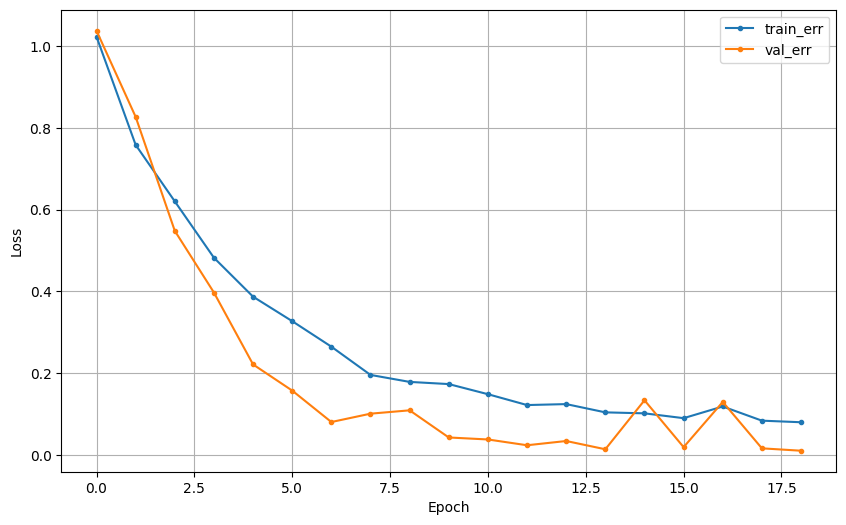

In [ ]:
model3.compile(optimizer = Adam(learning_rate=0.001), loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])


# EarlyStopping 설정 ------------
# min_delta 보다 개선이 안 됐으면 patience가 증가한다!!
min_de = 0.005  # 오차(loss)가 0.001이 되면 못참아.
pat = 5         # 5번까지는 오차 올라가는거 봐줄게.

es = EarlyStopping(monitor = 'val_loss', min_delta = min_de, patience = pat)
# --------------------------------


history3 = model3.fit(x_train, y_train, epochs=150, validation_split = 0.3, callbacks = [es, lr_scheduler]).history  # , callbacks = [mcp]

dl_history_plot(history3)

In [ ]:
pred3 = model3.predict(x_val)
pred_3 = pred3.argmax(axis=1)
print(confusion_matrix(y_val, pred_3))
print(classification_report(y_val, pred_3))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[[198   0   1]
 [  1 155   0]
 [  0   1 174]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       199
           1       0.99      0.99      0.99       156
           2       0.99      0.99      0.99       175

    accuracy                           0.99       530
   macro avg       0.99      0.99      0.99       530
weighted avg       0.99      0.99      0.99       530



### [다른 시도] 동적 동작 분류 후 모델 합치기

- 정적 모델링

In [9]:
# 데이터 로드 및 전처리
df_train = pd.read_csv(path + 'data01_train.csv')
df_test = pd.read_csv(path + 'data01_test.csv')

# 불필요한 컬럼 삭제
df_train.drop('subject', axis=1, inplace=True)
df_test.drop('subject', axis=1, inplace=True)

In [10]:
# 정적 동작 데이터셋 분리
static_data = df_train[df_train['Activity'].isin(['LAYING', 'SITTING', 'STANDING'])]
static_data['Activity'] = static_data['Activity'].map({'LAYING': 0, 'SITTING': 1, 'STANDING': 2})

<ipython-input-10-9cb02e1d1a67>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  static_data['Activity'] = static_data['Activity'].map({'LAYING': 0, 'SITTING': 1, 'STANDING': 2})


In [11]:
# 정적 Feature와 Label 분리
X_static = static_data.drop('Activity', axis=1)
y_static = static_data['Activity']

In [12]:
# 정적 데이터 분할
X_static_train, X_static_val, y_static_train, y_static_val = train_test_split(X_static, y_static, test_size=0.2, random_state=42)

In [13]:
# 정적 정규화
scaler = MinMaxScaler()
X_static_train = scaler.fit_transform(X_static_train)
X_static_val = scaler.transform(X_static_val)


In [14]:
# 정적 동작을 위한 Random Forest 모델 학습
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_static_train, y_static_train)

RandomForestClassifier(random_state=42)

---
- 동적 모델링

In [15]:
# 데이터 로드 및 전처리
df_train = pd.read_csv(path + 'data01_train.csv')
df_test = pd.read_csv(path + 'data01_test.csv')

# 불필요한 컬럼 삭제
df_train.drop('subject', axis=1, inplace=True)
df_test.drop('subject', axis=1, inplace=True)

In [16]:
# 동적 동작 데이터셋 분리
dynamic_data = df_train[df_train['Activity'].isin(['WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS'])]
dynamic_data['Activity'] = dynamic_data['Activity'].map({'WALKING': 0, 'WALKING_DOWNSTAIRS': 1, 'WALKING_UPSTAIRS': 2})

# 동적 Feature와 Label 분리
X_dynamic = dynamic_data.drop('Activity', axis=1)
y_dynamic = dynamic_data['Activity']


<ipython-input-16-d0735e8fbdcb>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dynamic_data['Activity'] = dynamic_data['Activity'].map({'WALKING': 0, 'WALKING_DOWNSTAIRS': 1, 'WALKING_UPSTAIRS': 2})


In [17]:
# 동적 데이터 분할
X_dynamic_train, X_dynamic_val, y_dynamic_train, y_dynamic_val = train_test_split(X_dynamic, y_dynamic, test_size=0.2, random_state=42)

In [18]:
# 동적 정규화
scaler = MinMaxScaler()
X_dynamic_train = scaler.fit_transform(X_dynamic_train)
X_dynamic_val = scaler.transform(X_dynamic_val)

In [19]:
# # 동적 정규화
# X_dynamic_train = scaler.fit_transform(X_dynamic_train)
# X_dynamic_val = scaler.transform(X_dynamic_val)

In [20]:
# 동적 동작을 위한 CNN-LSTM 모델 구성
# CNN은 공간적 특징을, LSTM은 시간적 특징을 학습하는 구조

K.clear_session()

dropout_num = 0.2

nfeatures = X_dynamic_train.shape[1]


model_dynamic = Sequential([
    Input(shape=(nfeatures, 1)),  # LSTM에 맞게 데이터를 (nfeatures, 1) 형식으로 입력
    Conv1D(64, kernel_size=3, activation='relu'),  # CNN 레이어 추가 / 1D CNN 레이어로, 시계열 데이터의 특징을 추출하는 역할
                                                   # kernel_size=3 : 세 개의 연속된 값에서 특징을 추출하도록 설정

    MaxPooling1D(pool_size=2),                     # CNN이 추출한 특징을 다운샘플링하여 중요한 정보만 남기도록
    BatchNormalization(),
    Dropout(dropout_num),

    Conv1D(64, kernel_size=3, activation='relu'),  # 시도) 64로 변경해보기
    MaxPooling1D(pool_size=2),
    BatchNormalization(),
    Dropout(dropout_num),

    LSTM(64, return_sequences=True),               # CNN에서 추출된 특징을 바탕으로 LSTM 레이어가 시계열적 특성을 학습
    BatchNormalization(),
    Dropout(dropout_num),

    LSTM(64),
    BatchNormalization(),
    Dropout(dropout_num),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(3, activation='softmax')
])



In [21]:
model_dynamic.compile(optimizer=Adam(learning_rate=0.001),  # 학습률 감소
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

In [22]:
# Step decay function
def step_decay(epoch):
    initial_lr = 0.001  # 초기 learning rate
    drop = 0.5         # learning rate 감소 비율
    epochs_drop = 10    # 몇 에포크마다 감소할지 설정
    lr = initial_lr * math.pow(drop, math.floor((1 + epoch) / epochs_drop))
    return lr

# # OneCycleLR 스케줄러 설정
# def one_cycle_lr_schedule(epochs, max_lr):
#     step_size = epochs // 2
#     lr_schedule = [max_lr * (x / step_size) if x <= step_size else max_lr * (1 - (x - step_size) / step_size) for x in range(epochs)]
#     return lr_schedule


# LearningRateScheduler 콜백 생성
lr_scheduler = LearningRateScheduler(step_decay)



# 학습 중 학습률 자동 감소
# lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

In [23]:
# EarlyStopping 및 ReduceLROnPlateau 설정
es = EarlyStopping(monitor='val_loss', patience=5, min_delta=0.005)

In [24]:
# 동적 모델 학습

history_dynamic = model_dynamic.fit(np.expand_dims(X_dynamic_train, axis=-1), y_dynamic_train,
                                    epochs=100, validation_split=0.2, batch_size=32, callbacks=[es, lr_scheduler]).history



Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 243ms/step - accuracy: 0.4835 - loss: 1.1805 - val_accuracy: 0.5094 - val_loss: 1.0760 - learning_rate: 0.0010
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 212ms/step - accuracy: 0.7423 - loss: 0.6312 - val_accuracy: 0.6179 - val_loss: 1.0638 - learning_rate: 0.0010
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 229ms/step - accuracy: 0.7847 - loss: 0.5518 - val_accuracy: 0.2972 - val_loss: 1.1709 - learning_rate: 0.0010
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 263ms/step - accuracy: 0.8407 - loss: 0.4474 - val_accuracy: 0.2830 - val_loss: 1.6780 - learning_rate: 0.0010
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 234ms/step - accuracy: 0.8543 - loss: 0.4117 - val_accuracy: 0.2830 - val_loss: 1.6312 - learning_rate: 0.0010
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 226ms/step - accuracy: 0.8690 - loss: 0.3316 - val_accuracy: 0.2830 - val_loss: 1.9946 - learning_rate: 0.0010
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 233ms/step - accuracy: 0.8795 - l

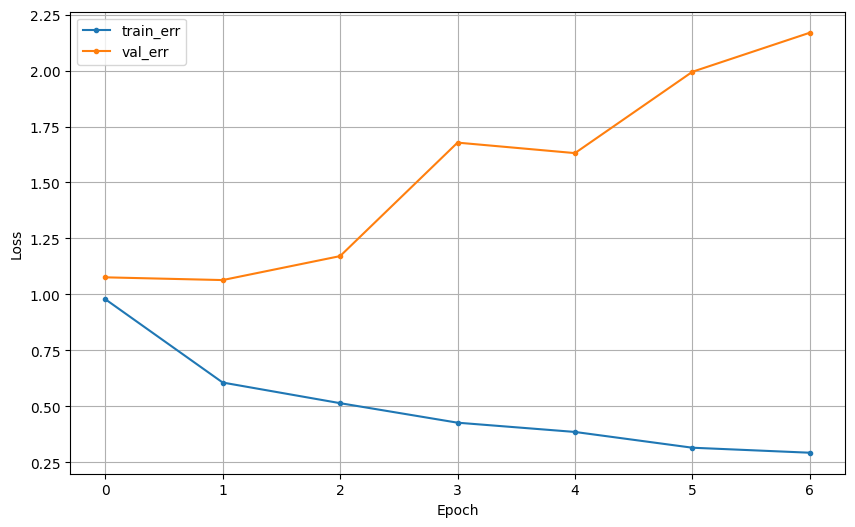

In [27]:
dl_history_plot(history_dynamic)

In [28]:
# 평가
pred = model_dynamic.predict(np.expand_dims(X_dynamic_val, axis=-1))
pred = pred.argmax(axis=1)

print(confusion_matrix(y_dynamic_val, pred))
print(classification_report(y_dynamic_val, pred))

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
[[  0   1 195]
 [  1   4 158]
 [  0   0 171]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       196
           1       0.80      0.02      0.05       163
           2       0.33      1.00      0.49       171

    accuracy                           0.33       530
   macro avg       0.38      0.34      0.18       530
weighted avg       0.35      0.33      0.17       530



In [ ]:
# 메타 모델로 정적과 동적 동작 구분 및 결합 모델 구현
def meta_model_predict(X):
    # 모델을 선택할 메타 모델
    if X['Activity'] in ['LAYING', 'SITTING', 'STANDING']:
        # 정적 동작일 때는 Random Forest 사용
        return rf_model.predict([X.drop('Activity')])[0]
    else:
        # 동적 동작일 때는 CNN-LSTM 사용
        X_reshaped = np.expand_dims(X.drop('Activity').values, axis=(0, -1))
        return model_dynamic.predict(X_reshaped).argmax()

In [ ]:
# 평가: 정적과 동적 데이터 결합 후 예측
combined_data = pd.concat([static_data, dynamic_data])

predictions = combined_data.apply(meta_model_predict, axis=1)

print(confusion_matrix(combined_data['Activity'], predictions))
print(classification_report(combined_data['Activity'], predictions))

Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/st

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### [다른 시도2]

In [ ]:
# 데이터 로드 및 전처리
df_train = pd.read_csv(path + 'data01_train.csv')
df_test = pd.read_csv(path + 'data01_test.csv')

# 불필요한 컬럼 삭제
df_train.drop('subject', axis=1, inplace=True)
df_test.drop('subject', axis=1, inplace=True)

In [ ]:
# 정적 동작 데이터셋 분리
static_data = df_train[df_train['Activity'].isin(['LAYING', 'SITTING', 'STANDING'])]
static_data['Activity'] = static_data['Activity'].map({'LAYING': 0, 'SITTING': 1, 'STANDING': 2})

# 정적 Feature와 Label 분리
X_static = static_data.drop('Activity', axis=1)
y_static = static_data['Activity']

<ipython-input-308-2cd3a60409d1>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  static_data['Activity'] = static_data['Activity'].map({'LAYING': 0, 'SITTING': 1, 'STANDING': 2})


In [ ]:
# 정적 데이터 모델링 (Random Forest)
rf_static = RandomForestClassifier(n_estimators=100, random_state=42)
rf_static.fit(X_static, y_static)

RandomForestClassifier(random_state=42)

In [ ]:
# 동적 동작 데이터셋 분리
dynamic_data = df_train[df_train['Activity'].isin(['WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS'])]
dynamic_data['Activity'] = dynamic_data['Activity'].map({'WALKING': 3, 'WALKING_DOWNSTAIRS': 4, 'WALKING_UPSTAIRS': 5})

# 동적 Feature와 Label 분리
X_dynamic = dynamic_data.drop('Activity', axis=1).values
y_dynamic = dynamic_data['Activity'].values

<ipython-input-310-91694e5a8918>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dynamic_data['Activity'] = dynamic_data['Activity'].map({'WALKING': 3, 'WALKING_DOWNSTAIRS': 4, 'WALKING_UPSTAIRS': 5})


In [ ]:
# CNN + LSTM 모델 구성
model_dynamic = Sequential([
    Input(shape=(nfeatures, 1)),  # LSTM에 맞게 데이터를 (nfeatures, 1) 형식으로 입력
    Conv1D(64, kernel_size=3, activation='relu'),  # CNN 레이어 추가 / 1D CNN 레이어로, 시계열 데이터의 특징을 추출하는 역할
                                                   # kernel_size=3 : 세 개의 연속된 값에서 특징을 추출하도록 설정

    MaxPooling1D(pool_size=2),                     # CNN이 추출한 특징을 다운샘플링하여 중요한 정보만 남기도록
    BatchNormalization(),
    Dropout(dropout_num),
    LSTM(64, return_sequences=True),               # CNN에서 추출된 특징을 바탕으로 LSTM 레이어가 시계열적 특성을 학습
    BatchNormalization(),
    Dropout(dropout_num),
    LSTM(64),
    BatchNormalization(),
    Dropout(dropout_num),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(3, activation='softmax')
])

In [ ]:
# 모델 앙상블을 통한 최종 예측 (각 모델의 예측 결과를 결합)
def ensemble_predict(X):
    # 정적 모델 예측
    static_preds = rf_static.predict(X)

    # 동적 모델 예측
    X_reshaped = X.reshape((X.shape[0], X.shape[1], 1))
    dynamic_preds = model_dynamic.predict(X_reshaped)
    dynamic_preds = dynamic_preds.argmax(axis=1) + 3  # 동적 범주의 값(3~5)으로 조정

    # 정적 모델과 동적 모델의 결과를 결합하여 최종 예측
    return np.concatenate((static_preds, dynamic_preds))

# 예시로 테스트 데이터에 대해 앙상블 예측
final_predictions = ensemble_predict(df_test.drop('Activity', axis=1).values)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 153ms/step


In [ ]:
pred = model_dynamic.predict(np.expand_dims(X_dynamic_val, axis=-1))
pred = pred.argmax(axis=1)

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 205ms/step


In [ ]:
print(confusion_matrix(y_dynamic_val, pred))
print(classification_report(y_dynamic_val, pred))

# 하............................이런~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

[[  0   0 196]
 [  0   0 163]
 [  0   0 171]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       196
           1       0.00      0.00      0.00       163
           2       0.32      1.00      0.49       171

    accuracy                           0.32       530
   macro avg       0.11      0.33      0.16       530
weighted avg       0.10      0.32      0.16       530



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### (3) 분류 모델 파이프라인 구성


* 세부 요구사항
    * 두 단계 모델을 통합하고, 새로운 데이터(test)에 대해서 최종 예측결과와 성능평가가 나오도록 함수로 만들기
    * 데이터 파이프라인 구축 : test데이터가 로딩되어 전처리 과정을 거치고, 예측 및 성능 평가 수행

* 예시
![](https://github.com/DA4BAM/image/blob/main/pipeline%20function.png?raw=true)

#### 1) 함수 만들기

#### 2) test 셋으로 예측하고 평가하기